In [1]:
import numpy as np
from PIL import ImageFont
from matplotlib import pyplot as plt
from modules.palette_generation import make_symbol2value_map, get_asciis

In [2]:
FONT = ImageFont.truetype("../fonts/Inconsolata-Regular.ttf", 11)
SYMBOLS = get_asciis()

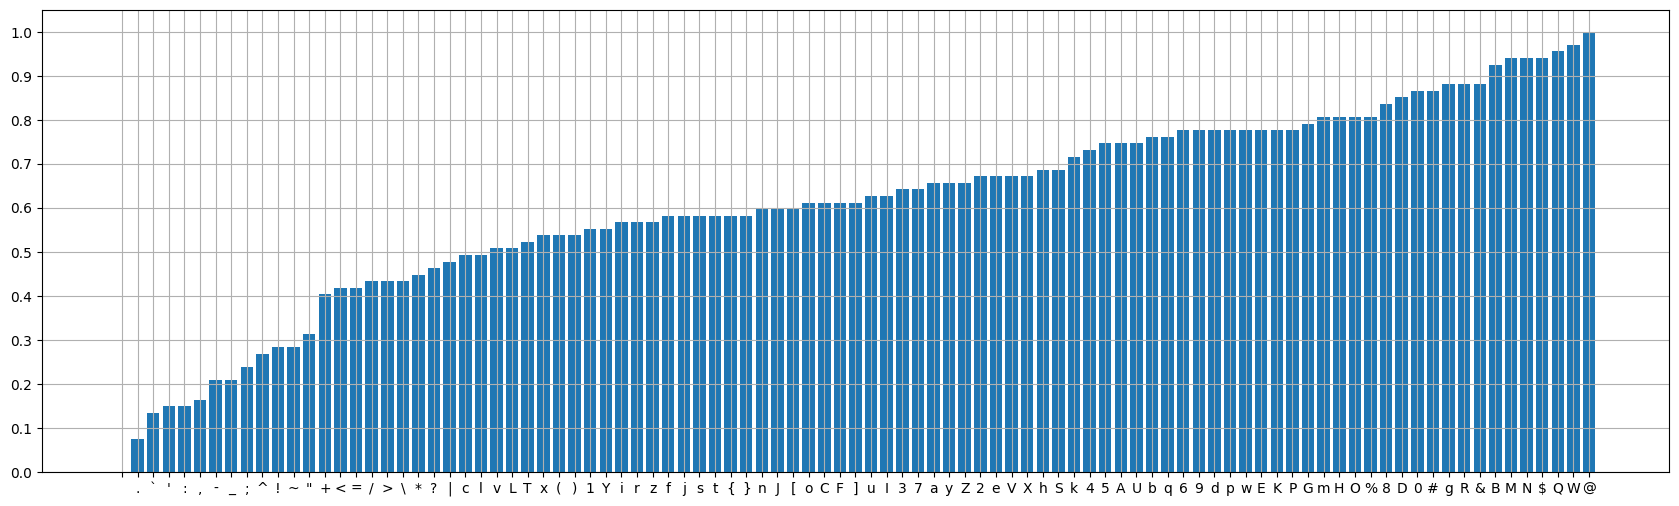

In [3]:
symbol2brightness = make_symbol2value_map(
    symbols=SYMBOLS,
    font=FONT,
    val_height=1,
    val_width=1,
    normalize=True)
brightness = [(s, b[0][0]) for s, b in symbol2brightness.items()]
brightness = sorted(brightness, key=lambda s_b: s_b[1])
plt.figure(figsize=(21, 6))
plt.yticks(np.arange(0.0, 1.1, 0.1))
plt.bar([sb[0] for sb in brightness], [sb[1] for sb in brightness])
plt.grid()

[['.', ' '], ["'", ',', '-', ':', '_', '`'], ['!', '"', ';', '^', '~'], ['+', '/', '<', '=', '>'], ['1', 'c', 'i', 'l', 'r', 'v', 'x', 'z', 'L', 'T', 'Y', '(', ')', '*', '?', '\\', '|'], ['2', '3', '7', 'a', 'e', 'f', 'j', 'n', 'o', 's', 't', 'u', 'y', 'C', 'F', 'I', 'J', 'V', 'Z', '[', ']', '{', '}'], ['4', '5', 'b', 'h', 'k', 'q', 'w', 'A', 'P', 'S', 'U', 'X'], ['0', '6', '8', '9', 'd', 'm', 'p', 'D', 'E', 'G', 'H', 'K', 'O', '#', '%', '&'], ['g', 'B', 'M', 'N', 'Q', 'R', 'W', '$', '@']]


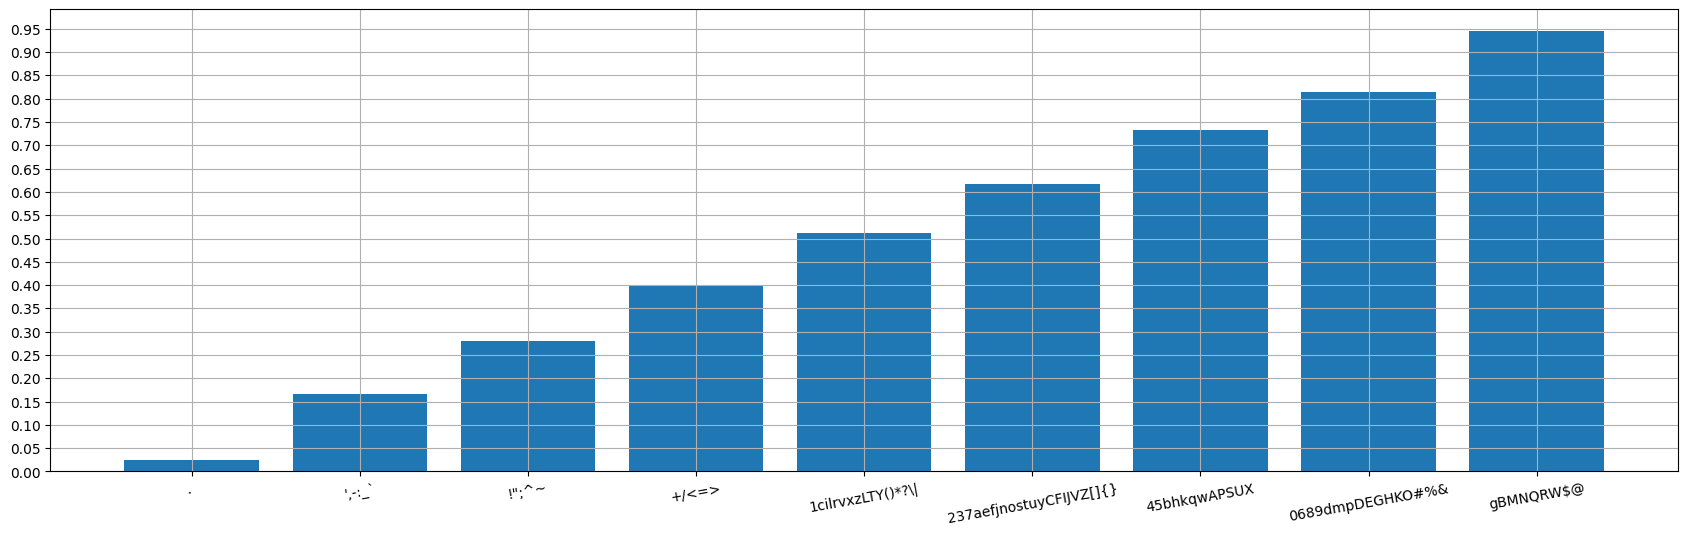

In [4]:
from modules.img2chars_1d_bin import make_1d_bin_palette

bins, mean_bin_brs = make_1d_bin_palette(SYMBOLS, FONT, bins=9, normalize=True)
print(bins)

plt.figure(figsize=(21, 6))
plt.yticks(np.arange(0, 1.1, 0.05))
plt.xticks(rotation=10)
plt.bar([''.join(l) for l in bins], mean_bin_brs)
plt.grid()

In [5]:
from modules.palette_generation import add_ansi_256_colors_grayscale


GS_SYMBOLS = add_ansi_256_colors_grayscale(get_asciis(), 4)

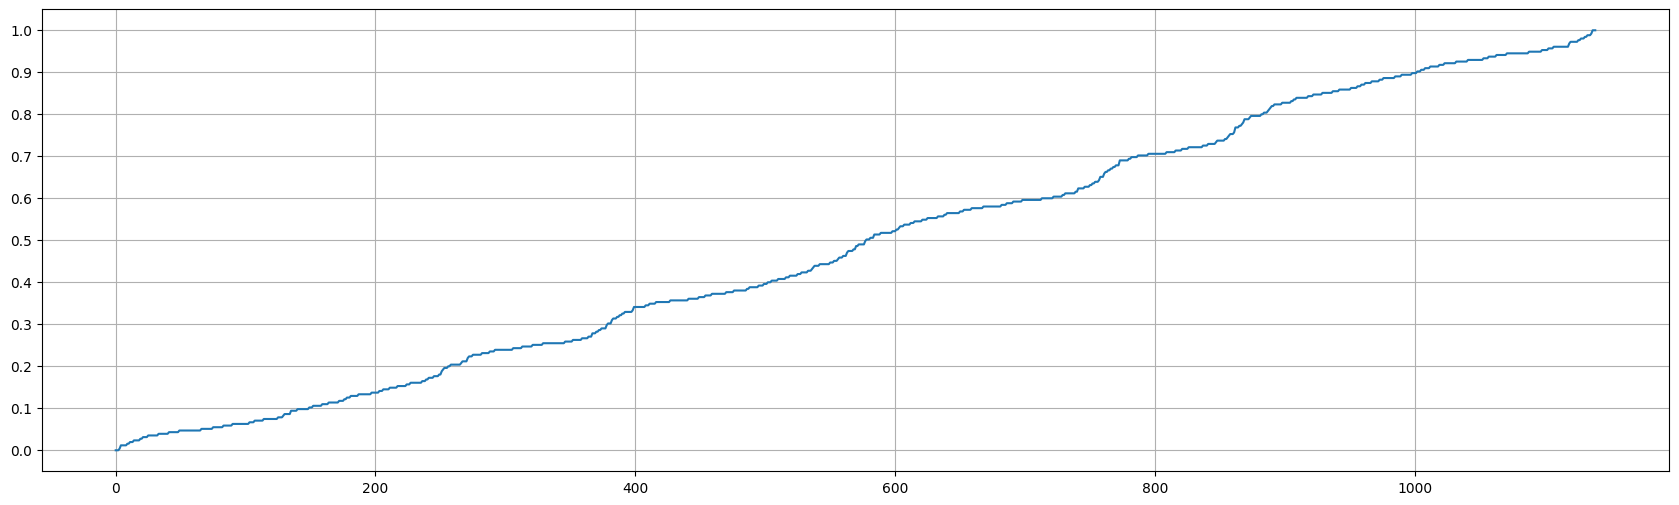

In [6]:
symbol2brightness = make_symbol2value_map(
    symbols=GS_SYMBOLS,
    font=FONT,
    val_height=1,
    val_width=1,
    normalize=True)
brightness = [(s, b[0][0]) for s, b in symbol2brightness.items()]
brightness = sorted(brightness, key=lambda s_b: s_b[1])
plt.figure(figsize=(21, 6))
plt.yticks(np.arange(0.0, 1.1, 0.1))
plt.plot([sb[1] for sb in brightness])
plt.grid()

[90, 88, 73, 70, 62, 87, 68, 40, 62, 106, 27, 85, 31, 78, 96, 77]


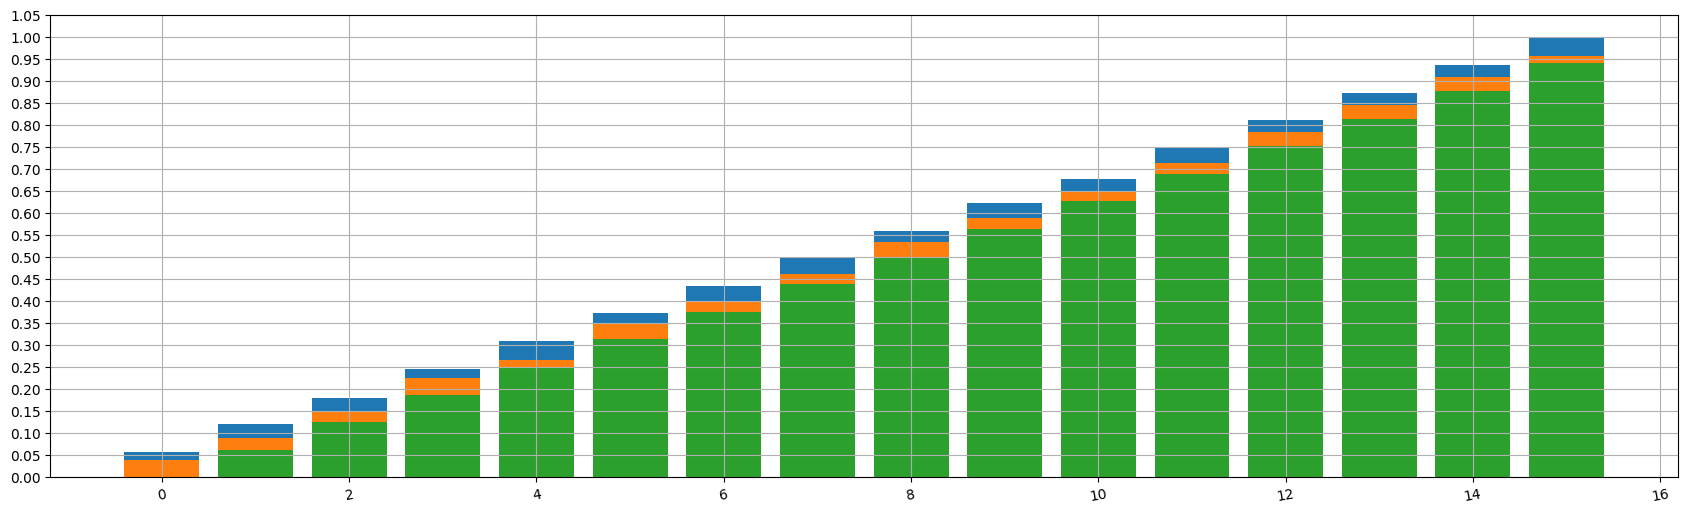

In [7]:
bins, mean_bin_brs = make_1d_bin_palette(GS_SYMBOLS, FONT, bins=16, normalize=True)
print([len(bin) for bin in bins])
min_bin_brs = [symbol2brightness[min(bin, key=lambda s: symbol2brightness[s])][0][0] for bin in bins]
max_bin_brs = [symbol2brightness[max(bin, key=lambda s: symbol2brightness[s])][0][0] for bin in bins]

plt.figure(figsize=(21, 6))
plt.yticks(np.arange(0, 1.1, 0.05))
plt.xticks(rotation=10)
plt.bar(np.arange(len(bins)), max_bin_brs)
plt.bar(np.arange(len(bins)), mean_bin_brs)
plt.bar(np.arange(len(bins)), min_bin_brs)
plt.grid()